In [16]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential 
#import optimizer and loss function
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_generator = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True)
train_data = train_generator.flow_from_directory(r'C:\Users\HP\Desktop\Deep_learning\datasets\Training', target_size=(256, 256), batch_size=32, class_mode='categorical')

Found 5600 images belonging to 4 classes.


In [18]:
test_generator = ImageDataGenerator(rescale=1./255)
test_data = test_generator.flow_from_directory(r'C:\Users\HP\Desktop\Deep_learning\datasets\Testing', target_size=(256, 256), batch_size=32, class_mode='categorical')

Found 1600 images belonging to 4 classes.


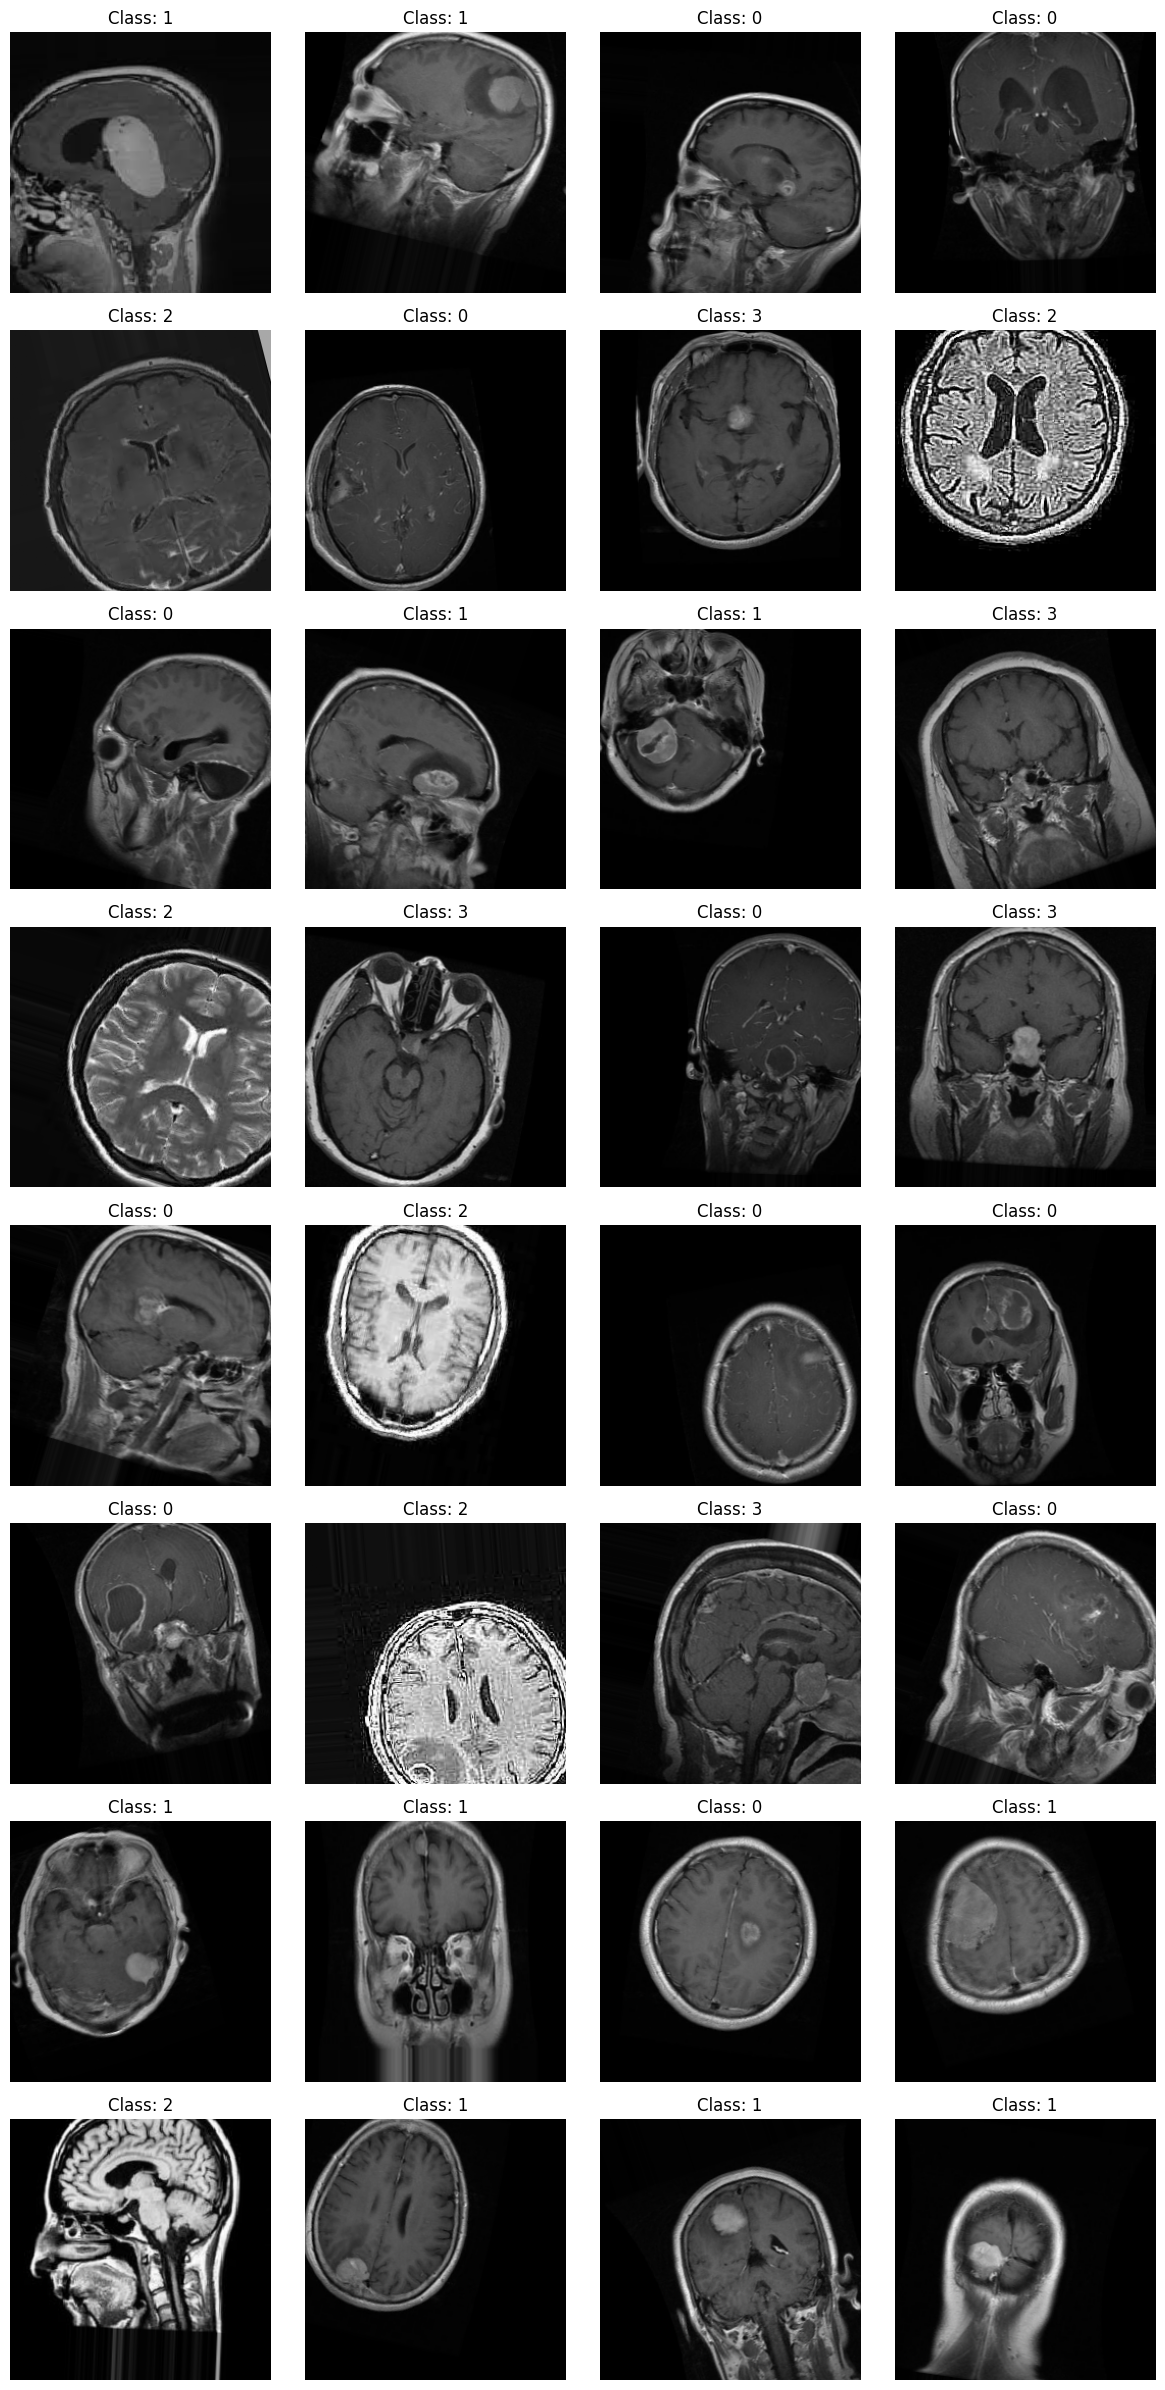

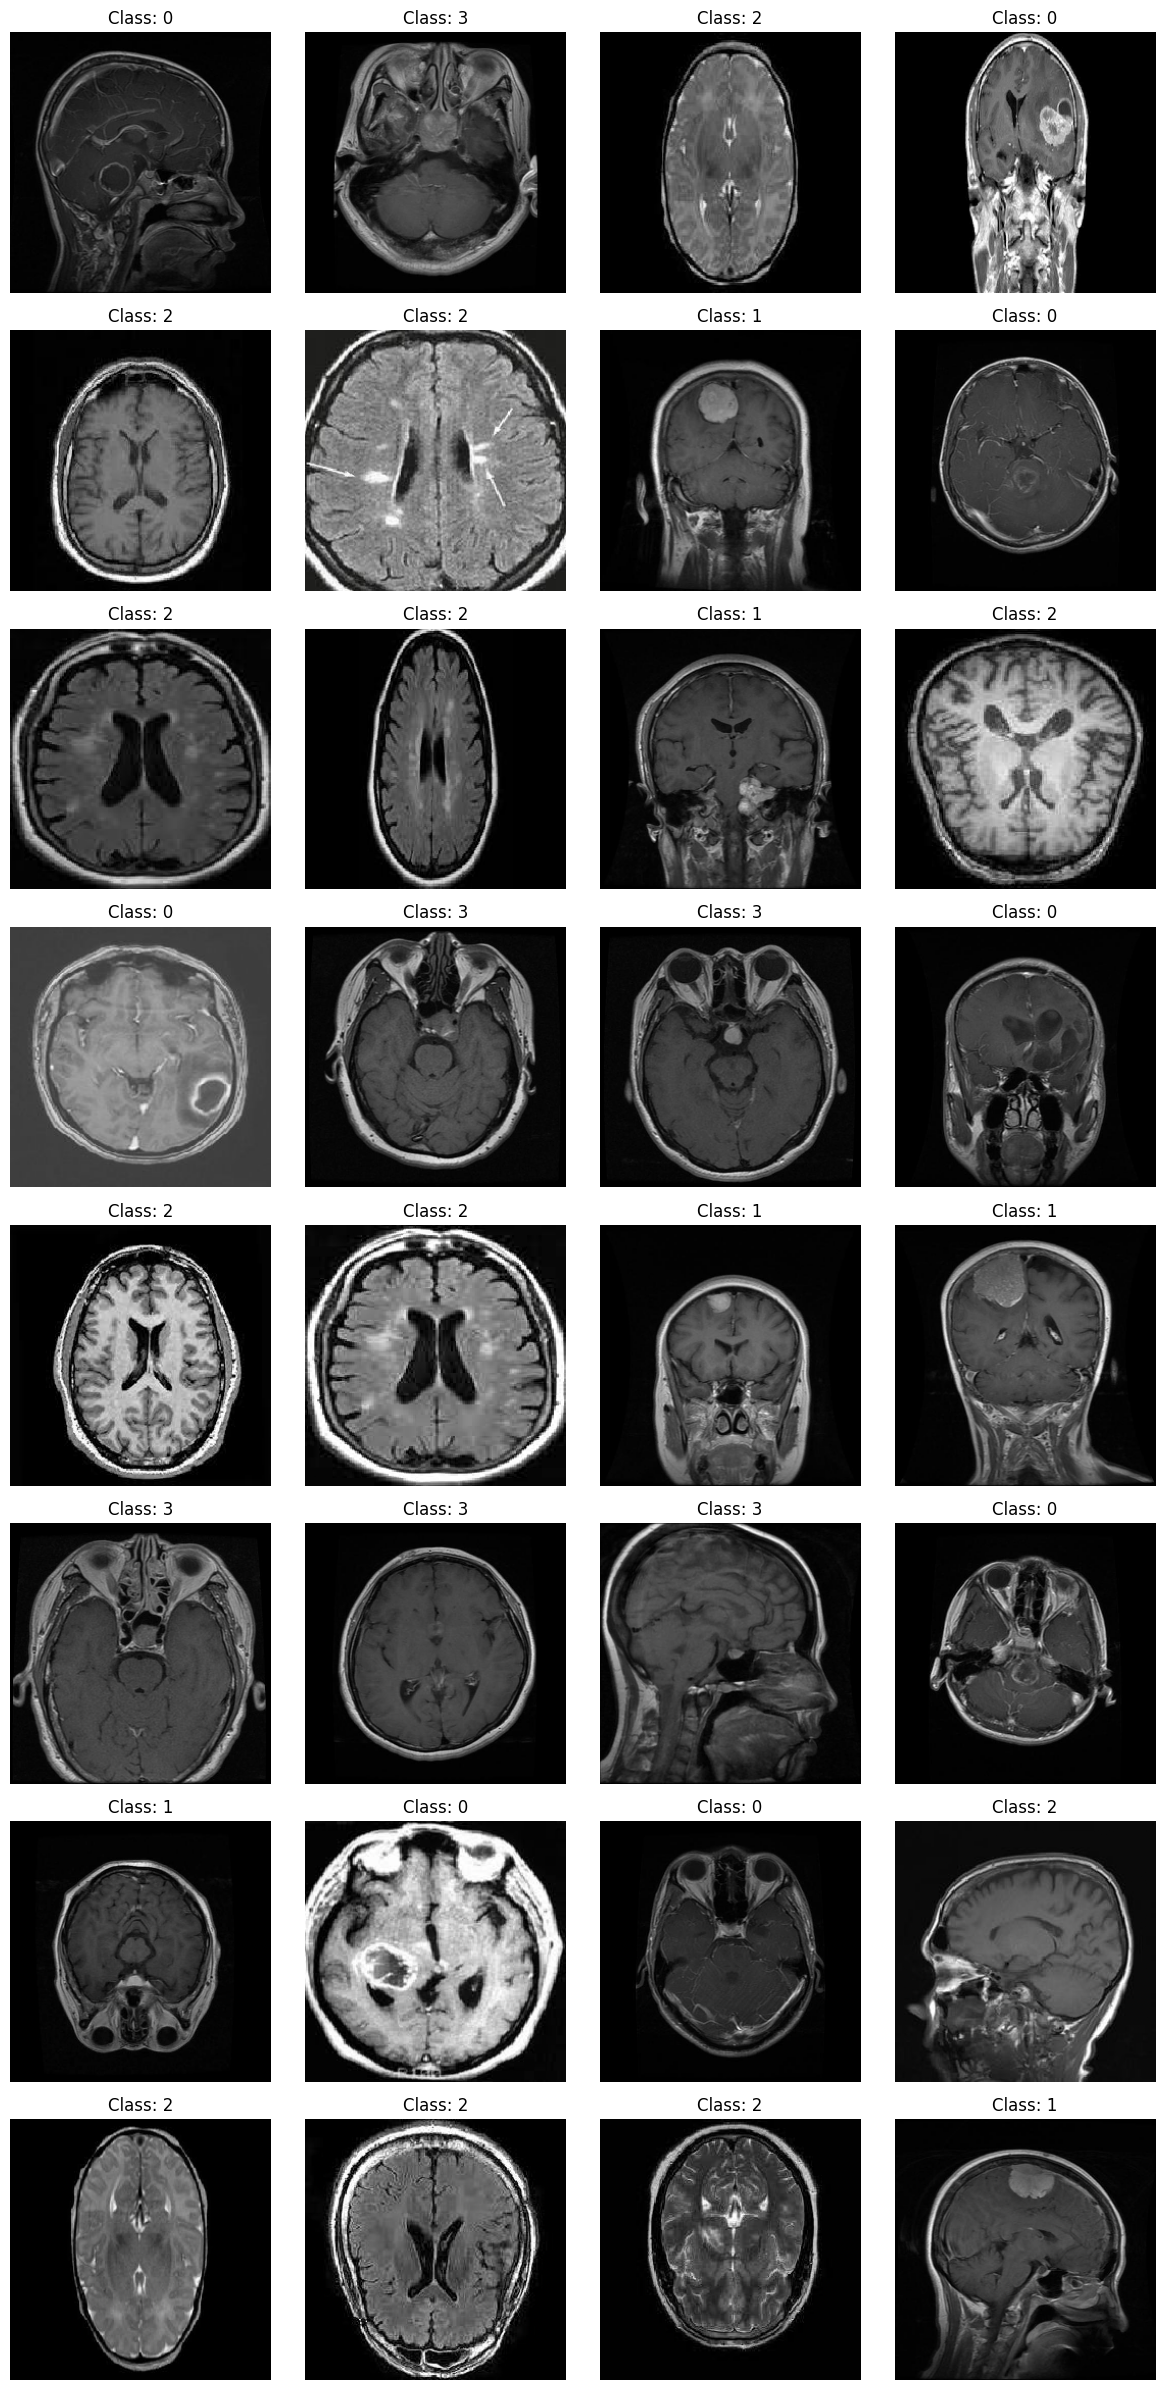

In [19]:
#@title Plotting an images
import math
# Function to plot images
def plot_images(images, labels):
    num_images = images.shape[0]
    num_rows = int(math.ceil(num_images / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(12, 3 * num_rows))
    for i in range(num_images):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(images[i])
        axes[row, col].set_title(f"Class: {np.argmax(labels[i])}")
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()


# Get a batch of training images and labels
train_images, train_labels = next(train_data)

# Get a batch of testing images and labels
test_images, test_labels = next(test_data)

# Plot a few images from the training and testing data
import matplotlib.pyplot as plt
import numpy as np
plot_images(train_images, train_labels)
plot_images(test_images, test_labels)



In [20]:
#CNN 
#conv---pooling---conv---pooling---flatten---dense---output
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='relu'),
    Dense(4, activation='softmax')
])

In [21]:
#optimizers and loss function
model_compile = model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
History = model.fit(train_data, epochs=10, validation_data=test_data, verbose=1)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 164s 935ms/step - accuracy: 0.4795 - loss: 1.0909 - val_accuracy: 0.6131 - val_loss: 1.0914
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 169s 963ms/step - accuracy: 0.5054 - loss: 1.0506 - val_accuracy: 0.6087 - val_loss: 1.1122
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 168s 959ms/step - accuracy: 0.5030 - loss: 1.0548 - val_accuracy: 0.6119 - val_loss: 1.1989
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 171s 975ms/step - accuracy: 0.5284 - loss: 1.0364 - val_accuracy: 0.5244 - val_loss: 1.8026
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 166s 950ms/step - accuracy: 0.5502 - loss: 0.9908 - val_accuracy: 0.5719 - val_loss: 1.5367
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 167s 951ms/step - accuracy: 0.5775 - loss: 0.9606 - val_accuracy: 0.5525 - val_loss: 1.7216
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 167s 950ms/step - accuracy: 0.5784 - loss: 0.9619 - val_accuracy: 0.6444 - val_loss: 1.3173
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 161s 919ms/step - accuracy: 0.5959 -

In [24]:
#download the model batch file
# Ensure the model is defined by running the cell where it is created (CELL INDEX: 5) before executing this cell
model.save("brain_tumor_model1.h5")

In [25]:

loss, acc = model.evaluate(test_data)
print("Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.6637 - loss: 1.3116
Accuracy: 0.6637499928474426


In [26]:
#load the model
from tensorflow.keras.models import load_model
model = load_model(r"C:\Users\HP\Desktop\Deep_learning\brain_tumor_model1.h5")  #model path

In [27]:
#list of classes  from the training data
class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
print("Class names:", class_names)

Class names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [29]:
from tensorflow.keras.preprocessing import image
import numpy as np


img = image.load_img(r"C:\Users\HP\Desktop\Deep_learning\datasets\Testing\meningioma\Te-aug-me_5.jpg", target_size=(256, 256))
img_array = image.img_to_array(img) / 255.0   #image to array and rescaling     
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension  because the model expects a batch of images as input, even if it's just one image. By adding an extra dimension, we create a batch of size 1, which allows us to pass the image through the model for prediction.
    
predictions = model.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


In [30]:

label = class_names[np.argmax(predictions)]
print("Predicted label:", label) 

Predicted label: glioma_tumor
